# Preprocessing Step
In this notebook we carry out the preprocessing step for our phase-dependent GMMs - determining the optimal mixture size

In [1]:
# load data
import numpy as np
import pickle
import math
import time
import sys
module_paths = ['']
for path in module_paths :
    if path not in sys.path:
        sys.path.append(path)

from utils_load_PHloc import (extract_PH_heatmaps_single_sample,
extract_heatmap_grid,
contour_heatmaps,
collect_paired_crit_sizes,
collect_indiv_crit_sizes)

from utils_load_PHloc import datasets_of_interest, injected_datasets_of_interest, levels_of_interest

# folder where you put the PHloc files
PH_folder = '' 

# choose desired anatomy: 'knee', 'long', 'both' (which is a merge of the birth-death points)
anatomy = 'knee'

# load file
filepath = PH_folder + 'PH_all_{}.pkl'.format(anatomy)
print('I will load',filepath)
PH_all_datasets = pickle.load(open(filepath, 'rb'))

# threshold value
THR = .5

# generate a new dictionary for truncated datasets
truncated_PH_all_datasets = {}
for i in datasets_of_interest:
    diagram = PH_all_datasets[i]
    truncated_PH_all_datasets[i] = diagram[diagram[:,1] >= diagram[:,0] + THR]
    
# print size of the diagrams
for i in datasets_of_interest:
    diagram1 = PH_all_datasets[i]
    diagram2 = truncated_PH_all_datasets[i]
print("done")

names = [injected_datasets_of_interest[i]+"_"+[str(x) for x in datasets_of_interest][i] for i in range(27)]

labels = ['CTRL_0%(1)', 'CTRL_0%(2)', 'CTRL_0%(3)', 'CTRL_0%(4)', 
          'U937_1%(1)', 'U937_1%(2)', 'U937_7%', 'U937_8%', 'U937_10%(1)', 'U937_10%(2)', 'U937_10%(3)', 
          'HL60_23%', 'HL60_25%(1)', 'HL60_25%(2)', 
          'P1_10%', 'P1_40%', 'P1_44%', 'P1_51%', 'P1_60%', 'P1_76%', 
          'P2_59%', 'P2_88%', 'P2_90%', 
          'MNC_53%', 'MNC_67%', 'MNC_75%', 'MNC_86%']

phases_of_interest = [0,0,0,0,
         1,1,1,1,1,1,1,
         1,1,1,
         1,2,2,2,2,2,
         2,2,2,
         2,2,2,2]

name_phase = [labels[i]+" [Phase "+str(phases_of_interest[i])+"]" for i in range(27)]

import matplotlib.pyplot as plt

################ PARAMETERS

# default values used: WEIGHTS = True (dirac masses weighted by persistence) ; SIGMA = .5

WEIGHTS = True
SIGMA = .5

# Binning parameters
XLIMS = np.array([[-15,0],[-10,10],[0,20]])
YLIMS = np.array([[-8,7],[-5,15],[0,20]])
NB_BINS_PER_SIDE = 100

# load modules and get ph0_sw
import pomegranate
import sklearn

import torch

from pomegranate.gmm import GeneralMixtureModel
from pomegranate.distributions import *

# extract quadrant points
phase0_index = [0,1,2,3]
phase1_index = [4,5,6,7,8,9,10,11,12,13,14]
phase2_index = [15,16,17,18,19,20,21,22,23,24,25,26]

pds = [truncated_PH_all_datasets[i] for i in datasets_of_interest]

ph0 = [pd[pd[:,2]==0,:2] for pd in pds]
ph1 = [pd[pd[:,2]==1,:2] for pd in pds]
ph2 = [pd[pd[:,2]==2,:2] for pd in pds]

ph0_sw = [pd0[(pd0[:,0]<0)*(pd0[:,1]<0),:] for pd0 in ph0]
ph1_sw = [pd1[(pd1[:,0]<0)*(pd1[:,1]<0),:] for pd1 in ph1]
ph1_nw = [pd1[(pd1[:,0]<0)*(pd1[:,1]>0),:] for pd1 in ph1]  
ph1_ne = [pd1[(pd1[:,0]>0)*(pd1[:,1]>0),:] for pd1 in ph1]
ph2_ne = [pd2[(pd2[:,0]>0)*(pd2[:,1]>0),:] for pd2 in ph2]


def single_weighted_contour_map(diag, sigma = 0.5, xlims = [-10,10], ylims = [-5,15], nb_bins_per_side = 100, option = "sklearn"):
    
    weights = diag[:,1]-diag[:,0]
    
    img = extract_heatmap_grid(diag, weights = weights, sigma = sigma,
                        xlim = xlims, ylim = ylims, nb_bins_per_side = nb_bins_per_side,
                         option = option)

    EXTENT = [-10, 10, -5, 15]

    plt.imshow(img, extent = EXTENT, cmap = 'magma')

    plt.contour(img, levels = 4, extent = EXTENT, #img.max()*np.arange(1,5)/5
               origin = 'upper', cmap = 'inferno_r')
    
    plt.tight_layout()
    plt.show() 

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.
I will load PH_all_knee.pkl
done


# PH2 NE

In [5]:

phase0_ph2ne = [ph2_ne[x] for x in phase0_index]
phase1_ph2ne = [ph2_ne[x] for x in phase1_index]
phase2_ph2ne = [ph2_ne[x] for x in phase2_index]
#stacking points of the same phase together
phase0_pts = np.vstack(phase0_ph2ne)
phase1_pts = np.vstack(phase1_ph2ne)
phase2_pts = np.vstack(phase2_ph2ne)

allphase_pts = np.vstack(ph2_ne)

# model sizes ranging from 2 to 20 (19 in total)
models = [] # list of 19 x 3 models
times = [] # 19 times
ind_loglikelihoods = [] # list of 19 x 3 x ... individual loglikelihoods
bics = [] # list of 19 x 3 x ... individual bics
bic_tols = [] # sum bic for each model size
# we are really only interested in "times" and "bic_tols"
for i in range(19):
    # start timing
    start_time = time.time()
    # fit model for phase 0
    model0 = pomegranate.gmm.GeneralMixtureModel.from_samples(
        pomegranate.MultivariateGaussianDistribution,   #Either single function, or list of functions
        n_components=i+2,     #Required if single function passed as first arg
        X=phase0_pts,     #data format: each row is a point-coordinate, each column is a dimension
        )
    model0.fit(
        X=phase0_pts,         #data format: each row is a coordinate, each column is a dimension
        weights = phase0_pts[:,1]-phase0_pts[:,0],  #List of weights. One for each point-coordinate
        stop_threshold = .001,  #Lower this value to get better fit but take longer. 
                                #   (sklearn likes better/slower fits than pomegrante by default)
        )
    model1 = pomegranate.gmm.GeneralMixtureModel.from_samples(
        pomegranate.MultivariateGaussianDistribution,   #Either single function, or list of functions
        n_components=i+2,     #Required if single function passed as first arg
        X=phase1_pts,     #data format: each row is a point-coordinate, each column is a dimension
        )
    model1.fit(
        X=phase1_pts,         #data format: each row is a coordinate, each column is a dimension
        weights = phase1_pts[:,1]-phase1_pts[:,0],  #List of weights. One for each point-coordinate
        stop_threshold = .001,  #Lower this value to get better fit but take longer. 
                                #   (sklearn likes better/slower fits than pomegrante by default)
        )
    model2 = pomegranate.gmm.GeneralMixtureModel.from_samples(
        pomegranate.MultivariateGaussianDistribution,   #Either single function, or list of functions
        n_components=i+2,     #Required if single function passed as first arg
        X=phase2_pts,     #data format: each row is a point-coordinate, each column is a dimension
        )
    model2.fit(
        X=phase2_pts,         #data format: each row is a coordinate, each column is a dimension
        weights = phase2_pts[:,1]-phase2_pts[:,0],  #List of weights. One for each point-coordinate
        stop_threshold = .001,  #Lower this value to get better fit but take longer. 
                                #   (sklearn likes better/slower fits than pomegrante by default)
        )
    times.append(time.time()-start_time)
    models.append([model0,model1,model2])
    
    # compute loglikelihoods on individual sample level
    
    # phase 0
    bic_sum = 0
    loglike_record0 = []
    bic_record0 = []
    for datas in phase0_ph2ne:
        n = datas.shape[0]
        loglike = np.sum(model0.log_probability(datas))
        loglike_record0.append(loglike)
        bic_record0.append(-2*loglike+math.log(n)*6*(i+2))
    bic_sum += sum(bic_record0)
    
    # phase 1
    loglike_record1 = []
    bic_record1 = []
    for datas in phase1_ph2ne:
        n = datas.shape[0]
        loglike = np.sum(model1.log_probability(datas))
        loglike_record1.append(loglike)
        bic_record1.append(-2*loglike+math.log(n)*6*(i+2))
    bic_sum += sum(bic_record1)
    
    # phase 2
    loglike_record2 = []
    bic_record2 = []
    for datas in phase2_ph2ne:
        n = datas.shape[0]
        loglike = np.sum(model2.log_probability(datas))
        loglike_record2.append(loglike)
        bic_record2.append(-2*loglike+math.log(n)*6*(i+2))
    bic_sum += sum(bic_record2)
    
    # appending...
    ind_loglikelihoods.append([loglike_record0, loglike_record1, loglike_record2])
    bics.append([bic_record0, bic_record1, bic_record2])
    bic_tols.append(bic_sum)
    
    print("model size = {} - done".format(i+2))
    

model size = 2 - done
model size = 3 - done
model size = 4 - done
model size = 5 - done
model size = 6 - done
model size = 7 - done
model size = 8 - done
model size = 9 - done
model size = 10 - done
model size = 11 - done
model size = 12 - done
model size = 13 - done
model size = 14 - done
model size = 15 - done
model size = 16 - done
model size = 17 - done
model size = 18 - done
model size = 19 - done
model size = 20 - done


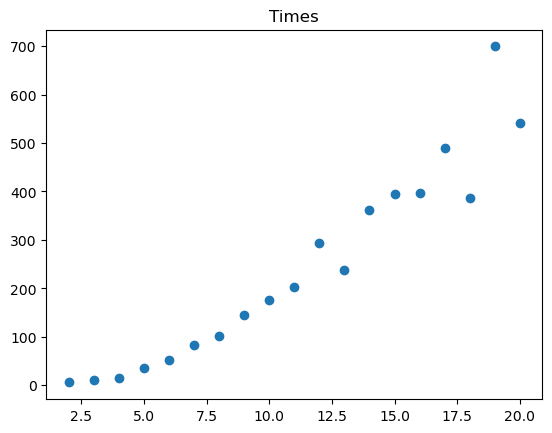

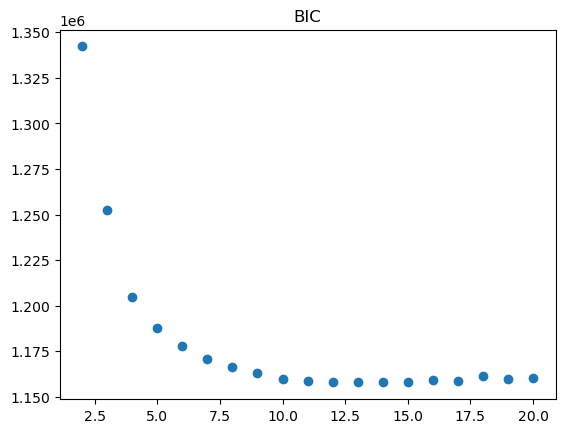

In [6]:
x_val = [i+2 for i in range(19)]
plt.scatter(x_val, times)
plt.title("Times")
plt.show()

plt.scatter(x_val, bic_tols)
plt.title("BIC")
plt.show()

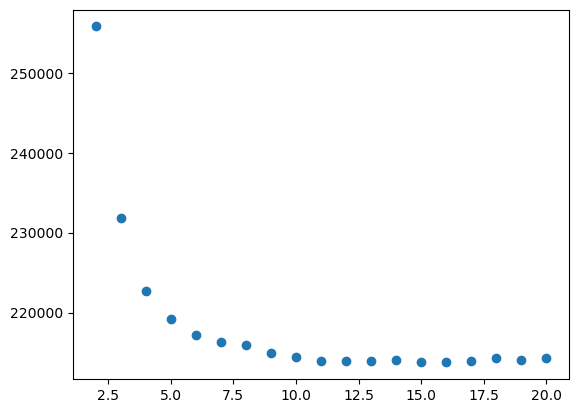

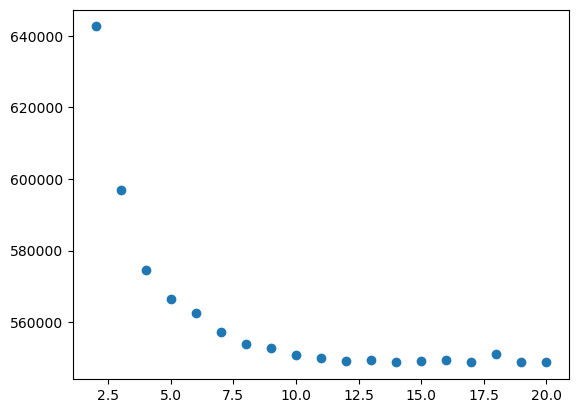

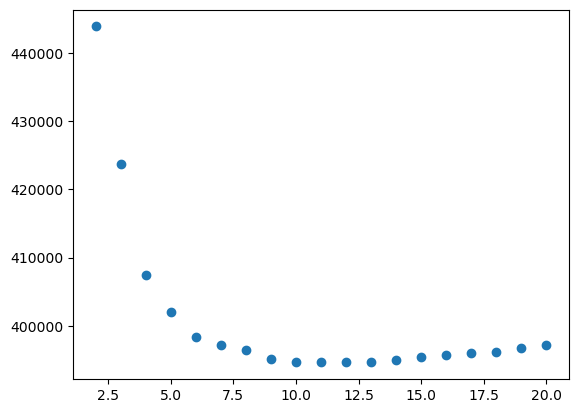

In [7]:
plt.scatter(x_val, [sum(bics[i][0]) for i in range(19)])
plt.show()

plt.scatter(x_val, [sum(bics[i][1]) for i in range(19)])
plt.show()

plt.scatter(x_val, [sum(bics[i][2]) for i in range(19)])
plt.show()

# PH1 SW

In [8]:
phase0_ph1sw = [ph1_sw[x] for x in phase0_index]
phase1_ph1sw = [ph1_sw[x] for x in phase1_index]
phase2_ph1sw = [ph1_sw[x] for x in phase2_index]


#stacking points of the same phase together
phase0_pts = np.vstack(phase0_ph1sw)
phase1_pts = np.vstack(phase1_ph1sw)
phase2_pts = np.vstack(phase2_ph1sw)

# model sizes ranging from 2 to 20 (19 in total)

models = [] # list of 19 x 3 models
times = [] # 19 times
ind_loglikelihoods = [] # list of 19 x 3 x ... individual loglikelihoods
bics = [] # list of 19 x 3 x ... individual bics
bic_tols = [] # sum bic for each model size
# we are really only interested in "times" and "bic_tols"
for i in range(19):
    # start timing
    start_time = time.time()
    # fit model for phase 0
    model0 = pomegranate.gmm.GeneralMixtureModel.from_samples(
        pomegranate.MultivariateGaussianDistribution,   #Either single function, or list of functions
        n_components=i+2,     #Required if single function passed as first arg
        X=phase0_pts,     #data format: each row is a point-coordinate, each column is a dimension
        )
    model0.fit(
        X=phase0_pts,         #data format: each row is a coordinate, each column is a dimension
        weights = phase0_pts[:,1]-phase0_pts[:,0],  #List of weights. One for each point-coordinate
        stop_threshold = .001,  #Lower this value to get better fit but take longer. 
                                #   (sklearn likes better/slower fits than pomegrante by default)
        )
    model1 = pomegranate.gmm.GeneralMixtureModel.from_samples(
        pomegranate.MultivariateGaussianDistribution,   #Either single function, or list of functions
        n_components=i+2,     #Required if single function passed as first arg
        X=phase1_pts,     #data format: each row is a point-coordinate, each column is a dimension
        )
    model1.fit(
        X=phase1_pts,         #data format: each row is a coordinate, each column is a dimension
        weights = phase1_pts[:,1]-phase1_pts[:,0],  #List of weights. One for each point-coordinate
        stop_threshold = .001,  #Lower this value to get better fit but take longer. 
                                #   (sklearn likes better/slower fits than pomegrante by default)
        )
    model2 = pomegranate.gmm.GeneralMixtureModel.from_samples(
        pomegranate.MultivariateGaussianDistribution,   #Either single function, or list of functions
        n_components=i+2,     #Required if single function passed as first arg
        X=phase2_pts,     #data format: each row is a point-coordinate, each column is a dimension
        )
    model2.fit(
        X=phase2_pts,         #data format: each row is a coordinate, each column is a dimension
        weights = phase2_pts[:,1]-phase2_pts[:,0],  #List of weights. One for each point-coordinate
        stop_threshold = .001,  #Lower this value to get better fit but take longer. 
                                #   (sklearn likes better/slower fits than pomegrante by default)
        )
    times.append(time.time()-start_time)
    models.append([model0,model1,model2])
    
    # compute loglikelihoods on individual sample level
    
    # phase 0
    bic_sum = 0
    loglike_record0 = []
    bic_record0 = []
    for datas in phase0_ph1sw:
        n = datas.shape[0]
        loglike = np.sum(model0.log_probability(datas))
        loglike_record0.append(loglike)
        bic_record0.append(-2*loglike+math.log(n)*6*(i+2))
    bic_sum += sum(bic_record0)
    
    # phase 1
    loglike_record1 = []
    bic_record1 = []
    for datas in phase1_ph1sw:
        n = datas.shape[0]
        loglike = np.sum(model1.log_probability(datas))
        loglike_record1.append(loglike)
        bic_record1.append(-2*loglike+math.log(n)*6*(i+2))
    bic_sum += sum(bic_record1)
    
    # phase 2
    loglike_record2 = []
    bic_record2 = []
    for datas in phase2_ph1sw:
        n = datas.shape[0]
        loglike = np.sum(model2.log_probability(datas))
        loglike_record2.append(loglike)
        bic_record2.append(-2*loglike+math.log(n)*6*(i+2))
    bic_sum += sum(bic_record2)
    
    # appending...
    ind_loglikelihoods.append([loglike_record0, loglike_record1, loglike_record2])
    bics.append([bic_record0, bic_record1, bic_record2])
    bic_tols.append(bic_sum)
    
    print("model size = {} - done".format(i+2))
    

model size = 2 - done
model size = 3 - done
model size = 4 - done
model size = 5 - done
model size = 6 - done
model size = 7 - done
model size = 8 - done
model size = 9 - done
model size = 10 - done
model size = 11 - done
model size = 12 - done
model size = 13 - done
model size = 14 - done
model size = 15 - done
model size = 16 - done
model size = 17 - done
model size = 18 - done
model size = 19 - done
model size = 20 - done


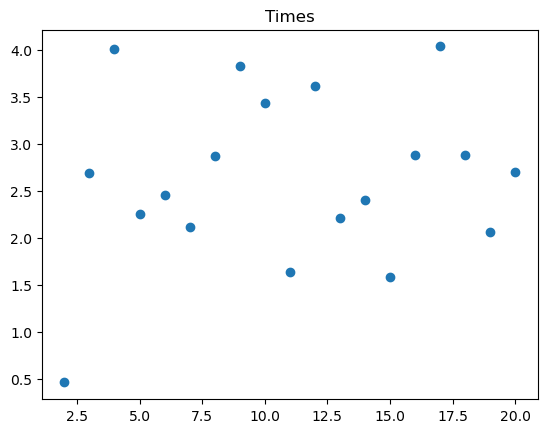

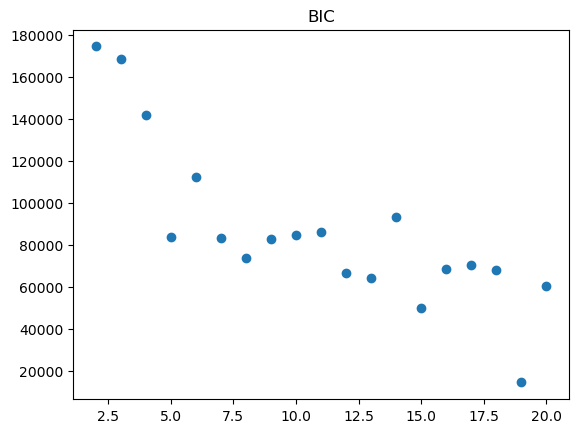

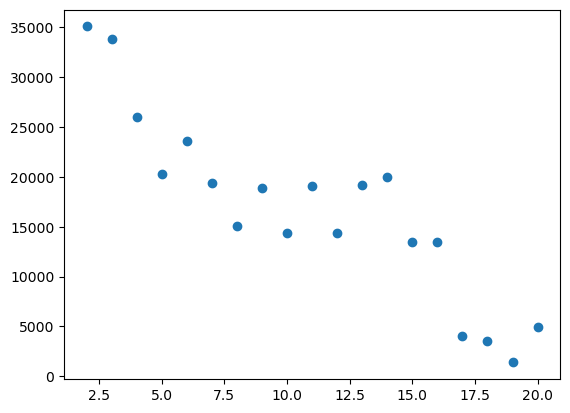

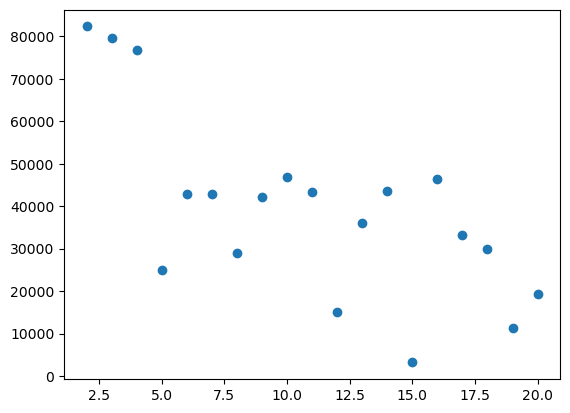

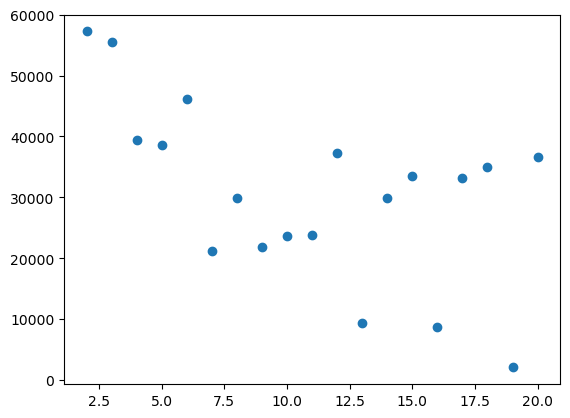

In [9]:
x_val = [i+2 for i in range(19)]
plt.scatter(x_val, times)
plt.title("Times")
plt.show()

plt.scatter(x_val, bic_tols)
plt.title("BIC")
plt.show()

plt.scatter(x_val, [sum(bics[i][0]) for i in range(19)])
plt.show()

plt.scatter(x_val, [sum(bics[i][1]) for i in range(19)])
plt.show()

plt.scatter(x_val, [sum(bics[i][2]) for i in range(19)])
plt.show()

# PH1 NE

In [10]:
phase0_ph1ne = [ph1_ne[x] for x in phase0_index]
phase1_ph1ne = [ph1_ne[x] for x in phase1_index]
phase2_ph1ne = [ph1_ne[x] for x in phase2_index]


#stacking points of the same phase together
phase0_pts = np.vstack(phase0_ph1ne)
phase1_pts = np.vstack(phase1_ph1ne)
phase2_pts = np.vstack(phase2_ph1ne)

allphase_pts = np.vstack(ph1_ne)

# model sizes ranging from 2 to 20 (19 in total)

models = [] # list of 19 x 3 models
times = [] # 19 times
ind_loglikelihoods = [] # list of 19 x 3 x ... individual loglikelihoods
bics = [] # list of 19 x 3 x ... individual bics
bic_tols = [] # sum bic for each model size
# we are really only interested in "times" and "bic_tols"
for i in range(19):
    # start timing
    start_time = time.time()
    # fit model for phase 0
    model0 = pomegranate.gmm.GeneralMixtureModel.from_samples(
        pomegranate.MultivariateGaussianDistribution,   #Either single function, or list of functions
        n_components=i+2,     #Required if single function passed as first arg
        X=phase0_pts,     #data format: each row is a point-coordinate, each column is a dimension
        )
    model0.fit(
        X=phase0_pts,         #data format: each row is a coordinate, each column is a dimension
        weights = phase0_pts[:,1]-phase0_pts[:,0],  #List of weights. One for each point-coordinate
        stop_threshold = .001,  #Lower this value to get better fit but take longer. 
                                #   (sklearn likes better/slower fits than pomegrante by default)
        )
    model1 = pomegranate.gmm.GeneralMixtureModel.from_samples(
        pomegranate.MultivariateGaussianDistribution,   #Either single function, or list of functions
        n_components=i+2,     #Required if single function passed as first arg
        X=phase1_pts,     #data format: each row is a point-coordinate, each column is a dimension
        )
    model1.fit(
        X=phase1_pts,         #data format: each row is a coordinate, each column is a dimension
        weights = phase1_pts[:,1]-phase1_pts[:,0],  #List of weights. One for each point-coordinate
        stop_threshold = .001,  #Lower this value to get better fit but take longer. 
                                #   (sklearn likes better/slower fits than pomegrante by default)
        )
    model2 = pomegranate.gmm.GeneralMixtureModel.from_samples(
        pomegranate.MultivariateGaussianDistribution,   #Either single function, or list of functions
        n_components=i+2,     #Required if single function passed as first arg
        X=phase2_pts,     #data format: each row is a point-coordinate, each column is a dimension
        )
    model2.fit(
        X=phase2_pts,         #data format: each row is a coordinate, each column is a dimension
        weights = phase2_pts[:,1]-phase2_pts[:,0],  #List of weights. One for each point-coordinate
        stop_threshold = .001,  #Lower this value to get better fit but take longer. 
                                #   (sklearn likes better/slower fits than pomegrante by default)
        )
    times.append(time.time()-start_time)
    models.append([model0,model1,model2])
    
    # compute loglikelihoods on individual sample level
    
    # phase 0
    bic_sum = 0
    loglike_record0 = []
    bic_record0 = []
    for datas in phase0_ph1ne:
        n = datas.shape[0]
        loglike = np.sum(model0.log_probability(datas))
        loglike_record0.append(loglike)
        bic_record0.append(-2*loglike+math.log(n)*6*(i+2))
    bic_sum += sum(bic_record0)
    
    # phase 1
    loglike_record1 = []
    bic_record1 = []
    for datas in phase1_ph1ne:
        n = datas.shape[0]
        loglike = np.sum(model1.log_probability(datas))
        loglike_record1.append(loglike)
        bic_record1.append(-2*loglike+math.log(n)*6*(i+2))
    bic_sum += sum(bic_record1)
    
    # phase 2
    loglike_record2 = []
    bic_record2 = []
    for datas in phase2_ph1ne:
        n = datas.shape[0]
        loglike = np.sum(model2.log_probability(datas))
        loglike_record2.append(loglike)
        bic_record2.append(-2*loglike+math.log(n)*6*(i+2))
    bic_sum += sum(bic_record2)
    
    # appending...
    ind_loglikelihoods.append([loglike_record0, loglike_record1, loglike_record2])
    bics.append([bic_record0, bic_record1, bic_record2])
    bic_tols.append(bic_sum)
    
    print("model size = {} - done".format(i+2))
    

model size = 2 - done
model size = 3 - done
model size = 4 - done
model size = 5 - done
model size = 6 - done
model size = 7 - done
model size = 8 - done
model size = 9 - done
model size = 10 - done
model size = 11 - done
model size = 12 - done
model size = 13 - done
model size = 14 - done
model size = 15 - done
model size = 16 - done
model size = 17 - done
model size = 18 - done
model size = 19 - done
model size = 20 - done


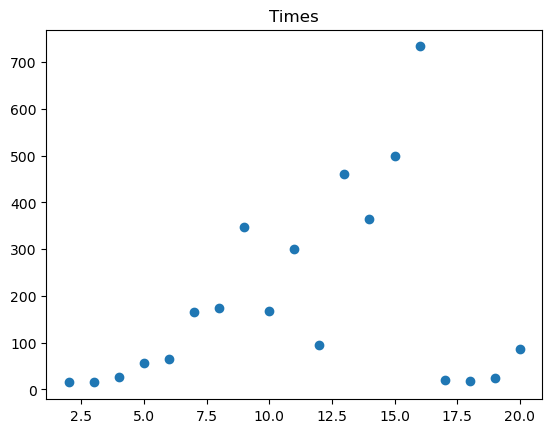

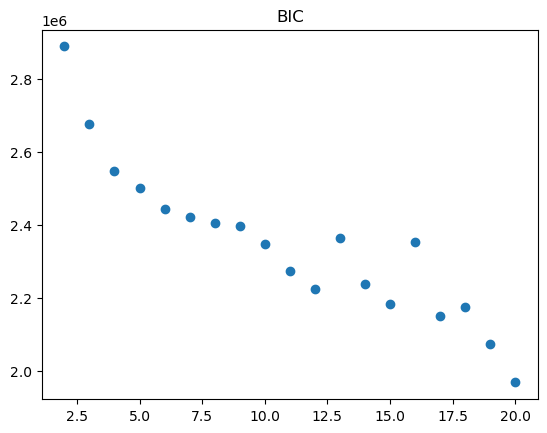

In [11]:
x_val = [i+2 for i in range(19)]
plt.scatter(x_val, times)
plt.title("Times")
plt.show()

plt.scatter(x_val, bic_tols)
plt.title("BIC")
plt.show()

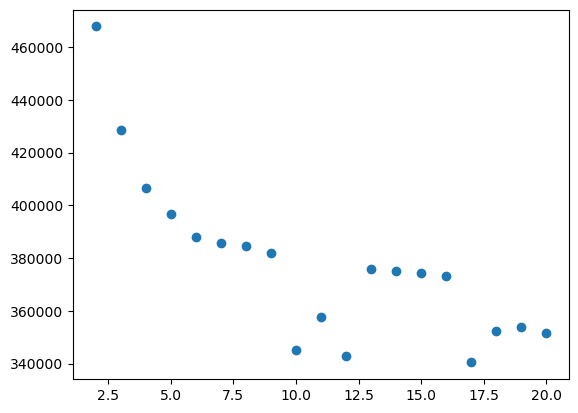

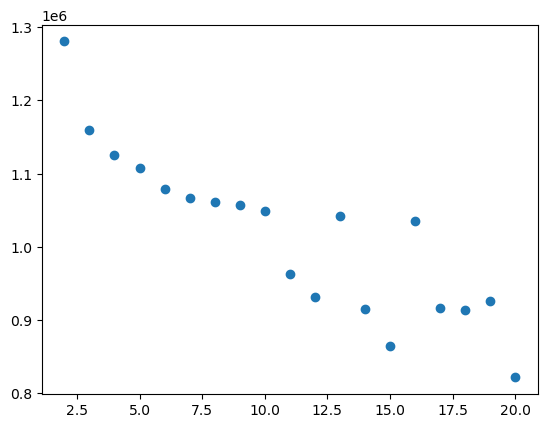

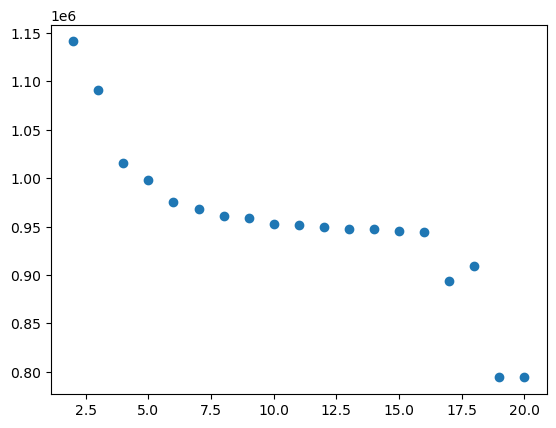

In [12]:
plt.scatter(x_val, [sum(bics[i][0]) for i in range(19)])
plt.show()

plt.scatter(x_val, [sum(bics[i][1]) for i in range(19)])
plt.show()

plt.scatter(x_val, [sum(bics[i][2]) for i in range(19)])
plt.show()

# PH0 SW

In [13]:

phase0_ph0sw = [ph0_sw[x] for x in phase0_index]
phase1_ph0sw = [ph0_sw[x] for x in phase1_index]
phase2_ph0sw = [ph0_sw[x] for x in phase2_index]

#stacking points of the same phase together
phase0_pts = np.vstack(phase0_ph0sw)
phase1_pts = np.vstack(phase1_ph0sw)
phase2_pts = np.vstack(phase2_ph0sw)

allphase_pts = np.vstack(ph0_sw)

# model sizes ranging from 2 to 20 (19 in total)

models = [] # list of 19 x 3 models
times = [] # 19 times
ind_loglikelihoods = [] # list of 19 x 3 x ... individual loglikelihoods
bics = [] # list of 19 x 3 x ... individual bics
bic_tols = [] # sum bic for each model size
# we are really only interested in "times" and "bic_tols"
for i in range(19):
    # start timing
    start_time = time.time()
    # fit model for phase 0
    model0 = pomegranate.gmm.GeneralMixtureModel.from_samples(
        pomegranate.MultivariateGaussianDistribution,   #Either single function, or list of functions
        n_components=i+2,     #Required if single function passed as first arg
        X=phase0_pts,     #data format: each row is a point-coordinate, each column is a dimension
        )
    model0.fit(
        X=phase0_pts,         #data format: each row is a coordinate, each column is a dimension
        weights = phase0_pts[:,1]-phase0_pts[:,0],  #List of weights. One for each point-coordinate
        stop_threshold = .001,  #Lower this value to get better fit but take longer. 
                                #   (sklearn likes better/slower fits than pomegrante by default)
        )
    model1 = pomegranate.gmm.GeneralMixtureModel.from_samples(
        pomegranate.MultivariateGaussianDistribution,   #Either single function, or list of functions
        n_components=i+2,     #Required if single function passed as first arg
        X=phase1_pts,     #data format: each row is a point-coordinate, each column is a dimension
        )
    model1.fit(
        X=phase1_pts,         #data format: each row is a coordinate, each column is a dimension
        weights = phase1_pts[:,1]-phase1_pts[:,0],  #List of weights. One for each point-coordinate
        stop_threshold = .001,  #Lower this value to get better fit but take longer. 
                                #   (sklearn likes better/slower fits than pomegrante by default)
        )
    model2 = pomegranate.gmm.GeneralMixtureModel.from_samples(
        pomegranate.MultivariateGaussianDistribution,   #Either single function, or list of functions
        n_components=i+2,     #Required if single function passed as first arg
        X=phase2_pts,     #data format: each row is a point-coordinate, each column is a dimension
        )
    model2.fit(
        X=phase2_pts,         #data format: each row is a coordinate, each column is a dimension
        weights = phase2_pts[:,1]-phase2_pts[:,0],  #List of weights. One for each point-coordinate
        stop_threshold = .001,  #Lower this value to get better fit but take longer. 
                                #   (sklearn likes better/slower fits than pomegrante by default)
        )
    times.append(time.time()-start_time)
    models.append([model0,model1,model2])
    
    # compute loglikelihoods on individual sample level
    
    # phase 0
    bic_sum = 0
    loglike_record0 = []
    bic_record0 = []
    for datas in phase0_ph0sw:
        n = datas.shape[0]
        loglike = np.sum(model0.log_probability(datas))
        loglike_record0.append(loglike)
        bic_record0.append(-2*loglike+math.log(n)*6*(i+2))
    bic_sum += sum(bic_record0)
    
    # phase 1
    loglike_record1 = []
    bic_record1 = []
    for datas in phase1_ph0sw:
        n = datas.shape[0]
        loglike = np.sum(model1.log_probability(datas))
        loglike_record1.append(loglike)
        bic_record1.append(-2*loglike+math.log(n)*6*(i+2))
    bic_sum += sum(bic_record1)
    
    # phase 2
    loglike_record2 = []
    bic_record2 = []
    for datas in phase2_ph0sw:
        n = datas.shape[0]
        loglike = np.sum(model2.log_probability(datas))
        loglike_record2.append(loglike)
        bic_record2.append(-2*loglike+math.log(n)*6*(i+2))
    bic_sum += sum(bic_record2)
    
    # appending...
    ind_loglikelihoods.append([loglike_record0, loglike_record1, loglike_record2])
    bics.append([bic_record0, bic_record1, bic_record2])
    bic_tols.append(bic_sum)
    
    print("model size = {} - done".format(i+2))
    

model size = 2 - done
model size = 3 - done
model size = 4 - done
model size = 5 - done
model size = 6 - done
model size = 7 - done
model size = 8 - done
model size = 9 - done
model size = 10 - done
model size = 11 - done
model size = 12 - done
model size = 13 - done
model size = 14 - done
model size = 15 - done
model size = 16 - done
model size = 17 - done
model size = 18 - done
model size = 19 - done
model size = 20 - done


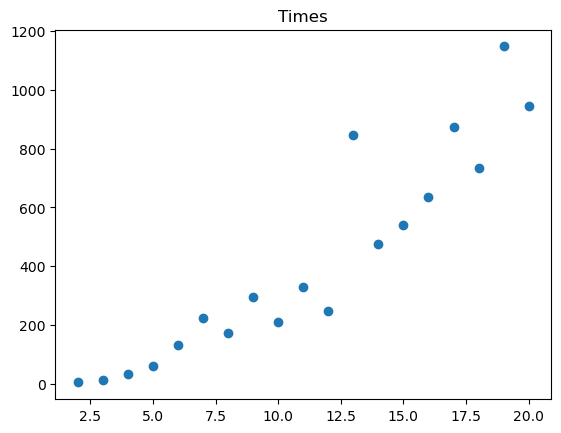

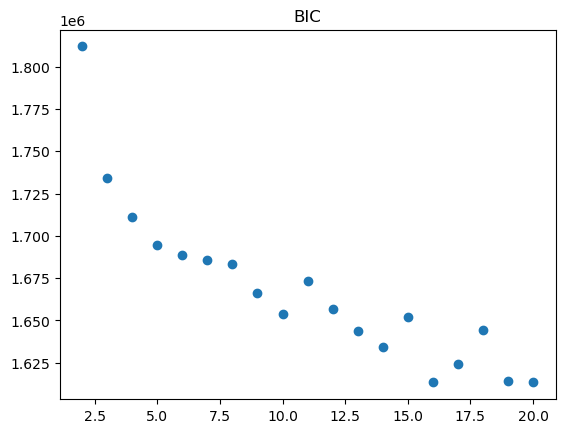

In [14]:
x_val = [i+2 for i in range(19)]
plt.scatter(x_val, times)
plt.title("Times")
plt.show()

plt.scatter(x_val, bic_tols)
plt.title("BIC")
plt.show()



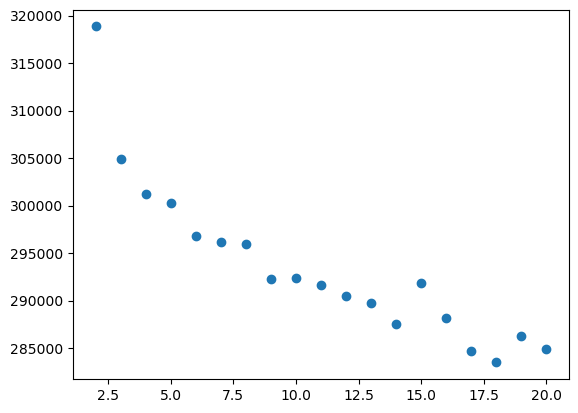

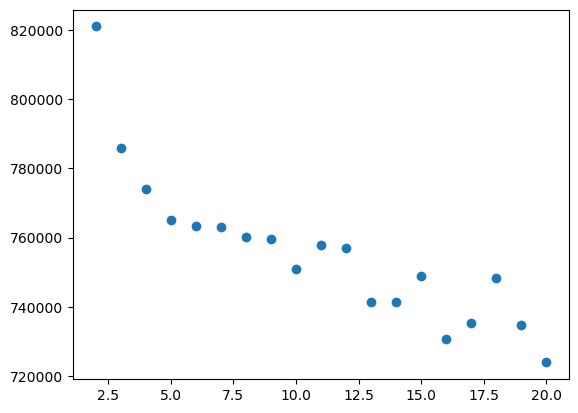

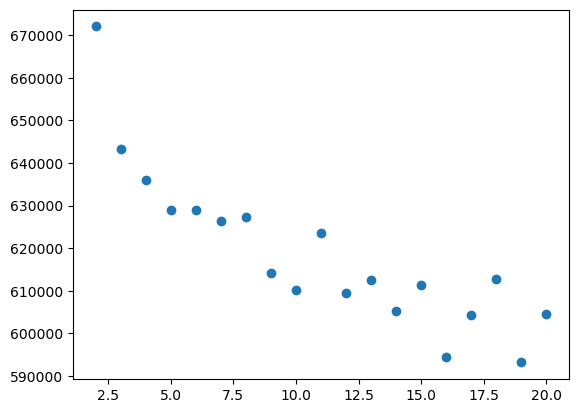

In [15]:
plt.scatter(x_val, [sum(bics[i][0]) for i in range(19)])
plt.show()

plt.scatter(x_val, [sum(bics[i][1]) for i in range(19)])
plt.show()

plt.scatter(x_val, [sum(bics[i][2]) for i in range(19)])
plt.show()

# PH1 NW

In [2]:
phase0_ph1nw = [ph1_nw[x] for x in phase0_index]
phase1_ph1nw = [ph1_nw[x] for x in phase1_index]
phase2_ph1nw = [ph1_nw[x] for x in phase2_index]

#stacking points of the same phase together
phase0_pts = np.vstack(phase0_ph1nw)
phase1_pts = np.vstack(phase1_ph1nw)
phase2_pts = np.vstack(phase2_ph1nw)

allphase_pts = np.vstack(ph1_nw)

# model sizes ranging from 2 to 20 (19 in total)

models = [] # list of 19 x 3 models
times = [] # 19 times
ind_loglikelihoods = [] # list of 19 x 3 x ... individual loglikelihoods
bics = [] # list of 19 x 3 x ... individual bics
bic_tols = [] # sum bic for each model size
# we are really only interested in "times" and "bic_tols"
for i in range(19):
    # start timing
    start_time = time.time()
    # fit model for phase 0
    model0 = pomegranate.gmm.GeneralMixtureModel.from_samples(
        pomegranate.MultivariateGaussianDistribution,   #Either single function, or list of functions
        n_components=i+2,     #Required if single function passed as first arg
        X=phase0_pts,     #data format: each row is a point-coordinate, each column is a dimension
        n_jobs = -1
        )
    model0.fit(
        X=phase0_pts,         #data format: each row is a coordinate, each column is a dimension
        weights = phase0_pts[:,1]-phase0_pts[:,0],  #List of weights. One for each point-coordinate
        stop_threshold = .001,  #Lower this value to get better fit but take longer. 
        n_jobs = -1                        #   (sklearn likes better/slower fits than pomegrante by default)
        )
    model1 = pomegranate.gmm.GeneralMixtureModel.from_samples(
        pomegranate.MultivariateGaussianDistribution,   #Either single function, or list of functions
        n_components=i+2,     #Required if single function passed as first arg
        X=phase1_pts,     #data format: each row is a point-coordinate, each column is a dimension
        n_jobs = -1
        )
    model1.fit(
        X=phase1_pts,         #data format: each row is a coordinate, each column is a dimension
        weights = phase1_pts[:,1]-phase1_pts[:,0],  #List of weights. One for each point-coordinate
        stop_threshold = .001,  #Lower this value to get better fit but take longer. 
        n_jobs = -1                        #   (sklearn likes better/slower fits than pomegrante by default)
        )
    model2 = pomegranate.gmm.GeneralMixtureModel.from_samples(
        pomegranate.MultivariateGaussianDistribution,   #Either single function, or list of functions
        n_components=i+2,     #Required if single function passed as first arg
        X=phase2_pts,     #data format: each row is a point-coordinate, each column is a dimension
        n_jobs = -1
        )
    model2.fit(
        X=phase2_pts,         #data format: each row is a coordinate, each column is a dimension
        weights = phase2_pts[:,1]-phase2_pts[:,0],  #List of weights. One for each point-coordinate
        stop_threshold = .001,  #Lower this value to get better fit but take longer. 
        n_jobs = -1                        #   (sklearn likes better/slower fits than pomegrante by default)
        )
    times.append(time.time()-start_time)
    models.append([model0,model1,model2])
    
    # compute loglikelihoods on individual sample level
    
    # phase 0
    bic_sum = 0
    loglike_record0 = []
    bic_record0 = []
    for datas in phase0_ph1nw:
        n = datas.shape[0]
        loglike = np.sum(model0.log_probability(datas))
        loglike_record0.append(loglike)
        bic_record0.append(-2*loglike+math.log(n)*6*(i+2))
    bic_sum += sum(bic_record0)
    
    # phase 1
    loglike_record1 = []
    bic_record1 = []
    for datas in phase1_ph1nw:
        n = datas.shape[0]
        loglike = np.sum(model1.log_probability(datas))
        loglike_record1.append(loglike)
        bic_record1.append(-2*loglike+math.log(n)*6*(i+2))
    bic_sum += sum(bic_record1)
    
    # phase 2
    loglike_record2 = []
    bic_record2 = []
    for datas in phase2_ph1nw:
        n = datas.shape[0]
        loglike = np.sum(model2.log_probability(datas))
        loglike_record2.append(loglike)
        bic_record2.append(-2*loglike+math.log(n)*6*(i+2))
    bic_sum += sum(bic_record2)
    
    # appending...
    ind_loglikelihoods.append([loglike_record0, loglike_record1, loglike_record2])
    bics.append([bic_record0, bic_record1, bic_record2])
    bic_tols.append(bic_sum)
    
    print("model size = {} - done".format(i+2))

model size = 2 - done
model size = 3 - done
model size = 4 - done
model size = 5 - done
model size = 6 - done
model size = 7 - done
model size = 8 - done
model size = 9 - done
model size = 10 - done
model size = 11 - done
model size = 12 - done
model size = 13 - done
model size = 14 - done
model size = 15 - done
model size = 16 - done
model size = 17 - done
model size = 18 - done
model size = 19 - done
model size = 20 - done


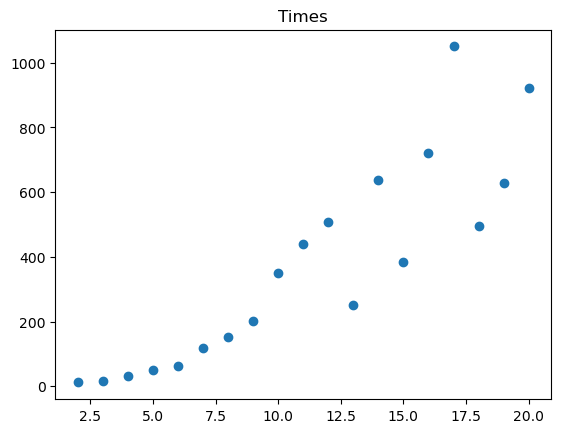

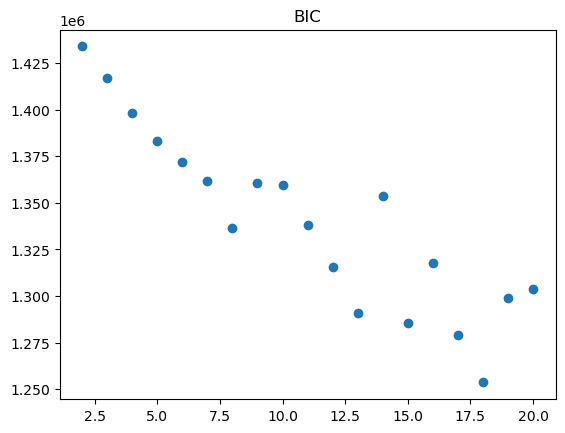

In [3]:
x_val = [i+2 for i in range(19)]
plt.scatter(x_val, times)
plt.title("Times")
plt.show()

plt.scatter(x_val, bic_tols)
plt.title("BIC")
plt.show()


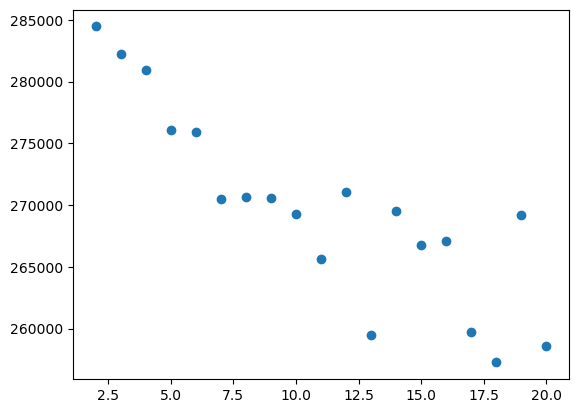

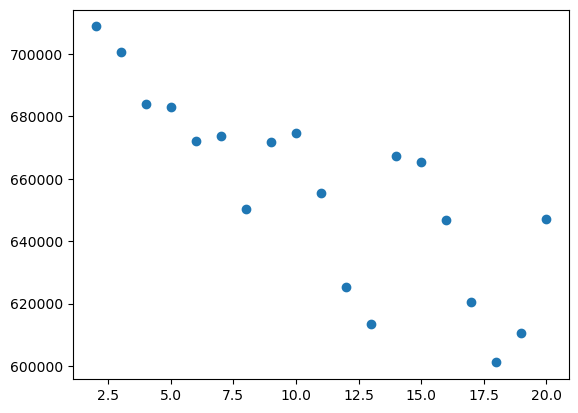

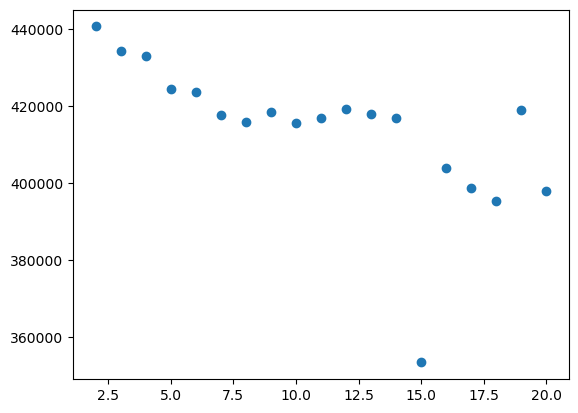

In [4]:
plt.scatter(x_val, [sum(bics[i][0]) for i in range(19)])
plt.show()

plt.scatter(x_val, [sum(bics[i][1]) for i in range(19)])
plt.show()

plt.scatter(x_val, [sum(bics[i][2]) for i in range(19)])
plt.show()